# **SkimLit Project (NLP)**

In [1]:
# Check for GPU
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-dc4f7c2c-c07b-21c5-b2db-3b9e82736e41)


In [2]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct.git
!ls pubmed-rct

Cloning into 'pubmed-rct'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 39 (delta 8), reused 5 (delta 5), pack-reused 25 (from 1)
Receiving objects: 100% (39/39), 177.08 MiB | 20.97 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Updating files: 100% (13/13), done.
PubMed_200k_RCT
PubMed_200k_RCT_numbers_replaced_with_at_sign
PubMed_20k_RCT
PubMed_20k_RCT_numbers_replaced_with_at_sign
README.md


In [3]:
# Check what files are in the PubMed_20K dataset
!ls pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign

dev.txt  test.txt  train.txt


We have three separate text files:

- train.txt
- dev.txt

- test.text

In [4]:
# start by using 20k datasets
data_dir = "/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/"

In [5]:
import os

# Check all of the filenames in the target directory
filenames = [data_dir + filename for filename in os.listdir(data_dir)]
filenames

['/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt',
 '/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt',
 '/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt']

# Data Preprocessing

## Data Understanding

```get_lines()``` fucntion က data visualize လုပ်ဖို့ပါ။

In [6]:
# data understanding
# visualize, visualize, visualize

def get_lines(filename):
  with open(filename, "r") as f:
    return f.readlines()

In [7]:
train_lines = get_lines(data_dir+'train.txt')
train_lines[:20]

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

text တွေက label နဲ့ data နဲ့ကရောနေတယ်။

ဒါကြောင့် function တစ်ခုဆောက်ရမယ်။

* Record the text before the `\t` as the label of the line.

* Record the text after the `\t` as the text of the line.

---

* Return all of the lines in the target text file as a list of dictionaries containing the key/value pairs:
  * `"line_number"` - the position of the line in the abstract (e.g. `3`).
  * `"target"` - the role of the line in the abstract (e.g. `OBJECTIVE`).
  * `"text"` - the text of the line in the abstract.
  * `"total_lines"` - the total lines in an abstract sample (e.g. `14`).
* Abstract ID's and newlines should be omitted from the returned preprocessed data.

Example returned preprocessed sample (a single line from an abstract):

Example returned preprocessed sample (a single line from an abstract):

```
[{'line_number': 0,
  'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'total_lines': 11},
  ...]
```

In [8]:
def preprocess_text_with_line_numbers(filename):

  # Get input lines first
  input_lines = get_lines(filename)

  abstract_lines = ""

  # empty list
  abstract_samples = []


  for line in input_lines:

    # id?
    if line.startswith("###"):
      abstract_id = line
      abstract_lines = ""

    # Check to se if line is a new line
    elif line.isspace():
      abstract_line_split = abstract_lines.splitlines() # split abstract into separate lines

      # iterate through each line in abstract
      # count them at the same time
      for abstract_line_number, abstract_line in enumerate(abstract_line_split):
        line_data = {} # create empty dict to store data from line

        # split target label from text
        target_text_split = abstract_line.split('\t')

        line_data['target'] = target_text_split[0]

        # get text data and lower it
        line_data['text'] = target_text_split[1].lower()

        # line number
        line_data['line_number'] = abstract_line_number

        # toal lines are in the abstract? (start from 0)
        line_data['total_lines'] = len(abstract_line_split) - 1

        abstract_samples.append(line_data)

    else: # if the above conditions aren't fulfilled, the line contains a labelled sentence
        abstract_lines += line

  return abstract_samples

In [9]:
train_samples = preprocess_text_with_line_numbers(data_dir + 'train.txt')
val_samples = preprocess_text_with_line_numbers(data_dir + 'dev.txt')
test_samples = preprocess_text_with_line_numbers(data_dir + 'test.txt')

len(train_samples), len(val_samples), len(test_samples)

(180040, 30212, 30135)

In [10]:
type(train_samples)

list

In [11]:
# check first abstract of our training data
train_samples[:10]

[{'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'line_number': 0,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'line_number': 1,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'line_number': 3,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'secondary outcome measures included the western ontari

In [12]:
import pandas as pd

train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)
train_df.head(10)

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11
5,METHODS,"serum levels of interleukin @ ( il-@ ) , il-@ ...",5,11
6,RESULTS,there was a clinically relevant reduction in t...,6,11
7,RESULTS,the mean difference between treatment arms ( @...,7,11
8,RESULTS,"further , there was a clinically relevant redu...",8,11
9,RESULTS,these differences remained significant at @ we...,9,11


### Check data distribution (class imbalance)

In [13]:
train_df.target.value_counts()

,count
target,
METHODS,59353
RESULTS,57953
CONCLUSIONS,27168
BACKGROUND,21727
OBJECTIVE,13839


<Axes: >

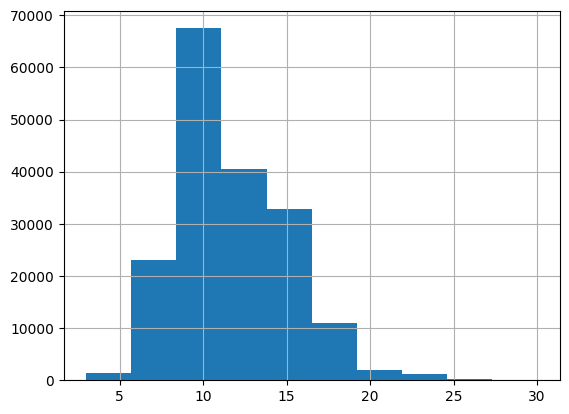

In [14]:
train_df.total_lines.hist()

### Get lists of sentences

When we build our deep learning model, one of its main input will be a list of strings (lines of abstract).

In [15]:
# convert abstract text lines into lists

train_sentences = train_df['text'].tolist()
val_sentences = val_df['text'].tolist()
test_sentences = test_df['text'].tolist()

train_sentences[:5]

['to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
 'secondary outcome measures included the western ontario and mcmaster universities osteoarthritis index scores , patient global assessment ( pga ) of the severity of knee oa , and @-min walk distance ( @mwd ) .']

## Data Encoding

### One Hot Encoding

In [16]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(sparse_output=False)
train_labels_one_hot = one_hot_encoder.fit_transform(train_df['target'].to_numpy().reshape(-1, 1))
val_labels_one_hot = one_hot_encoder.fit_transform(val_df['target'].to_numpy().reshape(-1, 1))
test_labels_one_hot = one_hot_encoder.fit_transform(test_df['target'].to_numpy().reshape(-1, 1))

In [17]:
train_labels_one_hot

array([[0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

### Label Encoding

In [18]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_labels_encoded = label_encoder.fit_transform(train_df["target"].to_numpy())
val_labels_encoded = label_encoder.transform(val_df["target"].to_numpy())
test_labels_encoded = label_encoder.transform(test_df["target"].to_numpy())

# Check what training
train_labels_encoded


array([3, 2, 2, ..., 4, 1, 1])

Now we've trained an instance of `LabelEncoder`, we can get the class names and number of classes using the `classes_` attribute.

In [19]:
# Get class names and number of classes from LabelEncoder instance
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
num_classes, class_names

(5,
 array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
       dtype=object))

# Model Training

https://arxiv.org/pdf/1612.05251

## Model 0 (Baseline)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Create a pipeline
model_0 = Pipeline([
    ('tf-idf', TfidfVectorizer()),
    ('clf', MultinomialNB())

])

model_0.fit(X = train_sentences, y=train_labels_encoded)

Pipeline(steps=[('tf-idf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [21]:
# evaluate
model_0.score(val_sentences, val_labels_encoded)

0.7218323844829869

72.18 % accuracy မဆိုးပါဘူး။ ဆိုတာ့ နောက်ထပ် model တေွက ဒီကောင့်ကို beat လုပ်ရမယ်။

In [22]:
baseline_preds = model_0.predict(val_sentences)
baseline_preds

array([4, 1, 3, ..., 4, 4, 1])

In [23]:
# Download helper functions script
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

--2026-06-05 16:27:08--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0.001s  

2026-06-05 16:27:08 (18.1 MB/s) - ‘helper_functions.py’ saved [10246/10246]



### Baseline Results

In [24]:
# Import calculate_results helper function
from helper_functions import calculate_results

# Calculate baseline results
baseline_results = calculate_results(y_true=val_labels_encoded,

                                     y_pred=baseline_preds)
baseline_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

---

# Prepare Data For Deep Seqeunce Models

ဒါက baseline model။ သူက ML algorithms နဲ့ run ထားတာ။ နောက်တစ်ဆင့်အနေနဲ့ Deep Learning Sequencce model တွေနဲ့ run မှာဆိုတော့ data ကိုနည်းနည်း ပြန် prepare လုပ်ရမယ်။

We've got a working baseline to try and improve upon.

But before we start building deeper models, we've got to create vectorization and embedding layers.

The vectorization layer will convert our text to numbers and the embedding layer will capture the relationships between those numbers.


In [26]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

### Sentence Length analysis

ဘာကြောင့် sentence length ကို ကြည့်ရတာလဲ?

Neural Networks (TensorFlow models) က input တွေကို တူညီတဲ့ shape ရှိဖို့ လိုပါတယ်။
```python
Sentence 1:

The treatment was effective (4 words)

Sentence 2:

The treatment significantly improved pain and mobility in elderly patients (10 words)
```

ဆိုရင် Model ထဲကို တိုက်ရိုက် မထည့်နိုင်ဘူး။ ဆိုတော့ Padding ကိုသုံးတယ်။ CNN မှာကြတော့ Padding က border ထည့်တာမလား။

အခုကြတော့ **Padding က တိုတဲ့ sentence တွေကို 0 တွေ ဖြည့်ပေးမယ်။**

``` python
[12, 45, 78, 33]

        ↓

[12, 45, 78, 33, 0, 0, 0, 0, 0, 0]

အခု sentence နှစ်ခုလုံး length = 10 ဖြစ်သွားပြီ။
```

ဆိုတော့ length size ကိုထားဖို့ကြတော့ Average length ရှာလိုက်တာပေါ့၊ ဘာလို့ဆို dataset ထဲမှာက sentence length တွေက မတူကြဘူးလေ။

Average length သိထားတော့ ```output_sequence_length``` ကိုသင့်တော်တဲ့ value သတ်မှတ်နိုင်တာပေါ့။

In [28]:
# how long is each sentence on avg?

sent_lens = [len(sentence.split()) for sentence in train_sentences]
avg_sent_len = np.mean(sent_lens)
avg_sent_len

np.float64(26.338269273494777)

Distribution of sentence lengths

(array([1.5999e+05, 1.8760e+04, 1.1510e+03, 9.9000e+01, 2.8000e+01,
        1.0000e+01, 2.0000e+00]),
 array([  1.        ,  43.14285714,  85.28571429, 127.42857143,
        169.57142857, 211.71428571, 253.85714286, 296.        ]),
 <BarContainer object of 7 artists>)

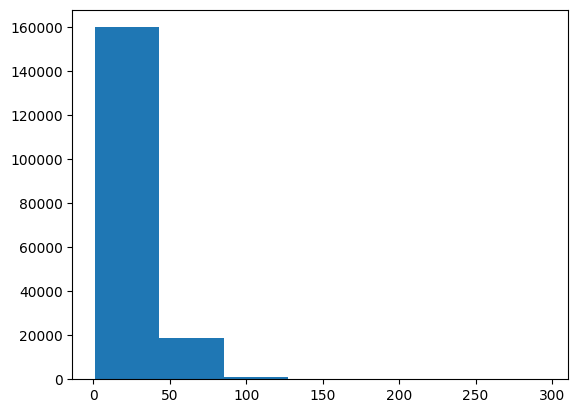

In [29]:
import matplotlib.pyplot as plt
plt.hist(sent_lens, bins=7)

Looks like the vast majority of sentences are between 0 and 50 tokens in length.

We can use NumPy's [`percentile`](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html) to find the value which covers 95% of the sentence lengths.

In [30]:
# how long of a sentence covers 95% of the lengths
output_seq_len = int(np.percentile(sent_lens, 95))
output_seq_len

55

ဆိုတော့က 95% သော training data တွေရဲ့ length က 55 tokens နဲ့ သူ့အောက်မှာပဲ။


အဲ့တာသိတော့ ငါတို့ tokenziation layer ဆောက်တဲ့အခါ အဲ့ same length သုံးလို့ရတယ်လေ။


ဆိုတော့ padding လုပ်တဲ့အခါ အများကြီးလုပ်စရာမလိုတော့ဘူးပေါ့။

ဒါမဲ့ မေးခွန်းက

> 🤔 **Question:** Why 95%?

We could use the max sentence length of the sentences in the training set.

In [31]:
max(sent_lens)

296

ဒါမဲ့ အဲ့လောက်ကြီးများနေရင် padding တွေချည်းလုပ်နေရတော့ data တေွက zero တွေချည်းဖြစ်ကုန်တော့မှာ။ အဲ့တာကြောင့်လေးးး။

# Text Vectorizer

We'll keep all the parameters default except for `max_tokens` (the number of unique words in our dataset) and `output_sequence_length` (our desired output length for each vectorized sentence).

Section 3.2 of the [PubMed 200k RCT paper](https://arxiv.org/pdf/1710.06071.pdf) states the vocabulary size of the PubMed 20k dataset as 68,000. So we'll use that as our `max_tokens` parameter.

In [32]:
# how many words are in our vocabulary
max_tokens = 68000

In [33]:
from tensorflow.keras.layers import TextVectorization

text_vectorizer = TextVectorization(max_tokens=max_tokens,
                                    output_sequence_length=output_seq_len)

In [35]:
# adapt vt to training sequences

text_vectorizer.adapt(train_sentences)

In [37]:
# Test vt

import random
target_sentence = random.choice(train_sentences)
print(f"Text:\n{target_sentence}")
print(f"\nLength of text: {len(target_sentence.split())}")
print(f"\nVectorized text:\n{text_vectorizer([target_sentence])}")

Text:
the primary end point for the surgical intervention was the successful completion of an appendectomy .

Length of text: 16

Vectorized text:
[[   2   56  199  294   11    2  306   38   10    2  845 1028    4   26
  5035    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0]]


Using the [`get_vocabulary()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/experimental/preprocessing/TextVectorization) method of our `text_vectorizer` we can find out a few different tidbits about our text.

In [39]:
# How many words in our training vocabulary?

rct_20k_text_vocab = text_vectorizer.get_vocabulary()
print(f"Number of words in vocabulary: {len(rct_20k_text_vocab)}"),
print(f"Most common words in the vocabulary: {rct_20k_text_vocab[:5]}")
print(f"Least common words in the vocabulary: {rct_20k_text_vocab[-5:]}")

Number of words in vocabulary: 64841
Most common words in the vocabulary: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('of')]
Least common words in the vocabulary: [np.str_('aainduced'), np.str_('aaigroup'), np.str_('aachener'), np.str_('aachen'), np.str_('aaacp')]


Configuration of Text Vecotrizer

And if we wanted to figure out the configuration of our `text_vectorizer` we can use the `get_config()` method.

In [41]:
text_vectorizer.get_config()

{'name': 'text_vectorization',
 'trainable': True,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'max_tokens': 68000,
 'standardize': 'lower_and_strip_punctuation',
 'split': 'whitespace',
 'ngrams': None,
 'output_mode': 'int',
 'output_sequence_length': 55,
 'pad_to_max_tokens': False,
 'sparse': False,
 'ragged': False,
 'vocabulary': None,
 'idf_weights': None,
 'encoding': 'utf-8',
 'vocabulary_size': 64841}

# Embedding

Once again, the main parameters we're concerned with here are the inputs and outputs of our `Embedding` layer.

The `input_dim` parameter defines the size of our vocabulary. And the `output_dim` parameter defines the dimension of the embedding output.

Once created, our embedding layer will take the integer outputs of our `text_vectorization` layer as inputs and convert them to feature vectors of size `output_dim`.

In [42]:
# create embedding layer

token_embed = layers.Embedding(input_dim=len(rct_20k_text_vocab),
                               output_dim = 128,
                               mask_zero=True,
                               name='token_embedding')

token_embed

<Embedding name=token_embedding, built=False>

In [45]:
print(f"Sentence before vecotrizaton:\n{target_sentence}\n")

vectorized_sentence = text_vectorizer([target_sentence])
print(f"Sentence after vectorization (before embedding):\n{vectorized_sentence}\n")

embedded_sentence = token_embed(vectorized_sentence)
print(f"Sentence after embedding:\n{embed_sentence}\n")
print(f"Embedd sentence shape: {embedded_sentence.shape}")

Sentence before vecotrizaton:
the primary end point for the surgical intervention was the successful completion of an appendectomy .

Sentence after vectorization (before embedding):
[[   2   56  199  294   11    2  306   38   10    2  845 1028    4   26
  5035    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0]]

Sentence after embedding:
[[[-0.00018083 -0.04944908  0.03384245 ... -0.00107478 -0.01234344
    0.03480214]
  [-0.00155225  0.02844575  0.03690905 ...  0.04026577 -0.04666383
    0.00063468]
  [-0.03895683  0.01457353 -0.01735006 ...  0.02202313 -0.03512534
   -0.00639591]
  ...
  [ 0.02697924  0.01763232 -0.00971768 ... -0.00949464  0.02293408
   -0.03939169]
  [ 0.02697924  0.01763232 -0.00971768 ... -0.00949464  0.02293408
   -0.03939169]
  [ 0.02697924  0.01763232 -0.00971768 ... -0.00949464  0.02293408
   -0.03939169]]]

# Create datasets (as fast as possible)

We've gone through all the trouble of preprocessing our datasets to be used with a machine learning model, however, there are still a few steps we can use to make them work faster with our models.

Namely, the `tf.data` API provides methods which enable faster data loading.

> 📖 **Resource:** For best practices on data loading in TensorFlow, check out the following:
* [tf.data: Build TensorFlow input pipelines](https://www.tensorflow.org/guide/data)
* [Better performance with the tf.data API](https://www.tensorflow.org/guide/data_performance)

The main steps we'll want to use with our data is to turn it into a `PrefetchDataset` of batches.

Doing so we'll ensure TensorFlow loads our data onto the GPU as fast as possible, in turn leading to faster training time.

To create a batched `PrefetchDataset` we can use the methods [`batch()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#batch) and [`prefetch()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#prefetch), the parameter [`tf.data.AUTOTUNE`](https://www.tensorflow.org/api_docs/python/tf/data#AUTOTUNE) will also allow TensorFlow to determine the optimal amount of compute to use to prepare datasets.

ဒီအပိုင်းက TensorFlow Dataset Optimization အကြောင်း ရှင်းပြထားတာပါ။

Model Architecture မပြောင်းဘဲ Training မြန်စေဖို့ Data Pipeline ကို optimize လုပ်နေခြင်း ဖြစ်ပါတယ်။

**ဆိုတော့ ဘာကြောင့် tf.data API သုံးတာလဲ?**

အရင်က Data တွေကို
```
model.fit(
    train_sentences,
    train_labels
)
```
လို တိုက်ရိုက်ပေးနိုင်တယ်။

ဒါပေမယ့် Dataset ကြီးလာရင်

- RAM usage များလာတယ်
- GPU စောင့်နေရတယ်
- Training နှေးသွားတယ်

In [66]:
# debug: float64 ဖြစ်နေတာ model train မရဘူး
train_labels_one_hot = train_labels_one_hot.astype("float32")
val_labels_one_hot = val_labels_one_hot.astype("float32")
test_labels_one_hot = test_labels_one_hot.astype("float32")

In [67]:
# turn our data into Tensorflow Datasets

train_dataset = tf.data.Dataset.from_tensor_slices((train_sentences, train_labels_one_hot))
train_dataset

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(5,), dtype=tf.float32, name=None))>

In [68]:
valid_dataset = tf.data.Dataset.from_tensor_slices((val_sentences, val_labels_one_hot))

test_dataset = tf.data.Dataset.from_tensor_slices((test_sentences, test_labels_one_hot))

ဒီအချိန် Dataset object ဖြစ်သွားတယ်။

```
Sentence 1 -> Label 1
Sentence 2 -> Label 2
Sentence 3 -> Label 3
...
```

In [69]:
# take the tensorslice dataset and turn them into prefected batches
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
valid_dataset = valid_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>

> **Batch**: Neural Network က Sample တစ်ခုချင်းစီ မသင်ဘူး။ Batch လိုက် သင်တယ်။
```python
Batch 1:
32 sentences

Batch 2:
32 sentences

Batch 3:
32 sentences
```

> **Prefetch**: ဒီက အရေးကြီးဆုံး။ GPU က Training လုပ်နေချိန် CPU က Next Batch ကို ကြိုတင် ပြင်ထားပေးတယ်။

```python
# Without Prefetch

GPU waits
↓
CPU loads data
↓
GPU trains
↓
CPU loads next batch
↓
GPU waits again

GPU အချိန်ကုန်တယ်။
```

```python
# With Prefetch

GPU trains Batch 1

while

CPU prepares Batch 2
```

```python
# Visualization

Batch 1 -> GPU

Batch 2 -> Ready

Batch 3 -> Ready

GPU မစောင့်ရတော့ဘူး။
```

> **AUTOTUNE**: TensorFlow ကို "CPU cores ဘယ်လောက်သုံးရမလဲ၊ prefetch size ဘယ်လောက်ထားရမလဲ မင်းဘာသာဆုံးဖြတ်" လို့ ပြောလိုက်တာ။ Laptop, CPU, RAM, GPU ပေါ်မူတည်ပြီး best performance ရအောင် ချိန်ညှိပေးတယ်။



# Model 1: Conv1D (+ token embedding)

In [70]:
inputs = layers.Input(shape=[], dtype=tf.string)
text_vectors = text_vectorizer(inputs)

token_embedding = token_embed(text_vectors)

x = layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(token_embedding)
x = layers.GlobalAveragePooling1D()(x) # condense the output of our feature vector
outputs = layers.Dense(5, activation='softmax')(x)

model_1 = tf.keras.Model(inputs, outputs)

# Compile
model_1.compile(optimizer = tf.keras.optimizers.Adam(),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_3' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 55)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_embedding (Embedding)     │ (None, 55, 128)        │     8,299,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 55, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,340,997 (31.82 MB)

 Trainable params: 8,340,997 (31.82 MB)

 Non-trainable params: 0 (0.00 B)

**ဘာကြောင့် Dataset အပြည့် မသုံးသေးတာလဲ?**

PubMed Dataset မှာ sentence ~200,000 လောက်ရှိတာကြောင့်

Training time ကြာနိုင်တယ်
GPU ရှိရင်တောင် experiment တစ်ခုချင်းစီ နှေးနိုင်တယ်

ဒါကြောင့် အစပိုင်းမှာ Training dataset ရဲ့ 10%, Validation dataset ရဲ့ 10% ကိုပဲ သုံးမယ်။ အကြမ်းဖျင်းအားဖြင့် 18,000 samples လောက် ဖြစ်တယ်။

> 🔑 **Note:** It's a standard practice in machine learning to test your models on smaller subsets of data first to make sure they work before scaling them to larger amounts of data. You should aim to run many smaller experiments rather than only a handful of large experiments. And since your time is limited, one of the best ways to run smaller experiments is to reduce the amount of data you're working with (10% of the full dataset is usually a good amount, as long as it covers a similar distribution).

In [72]:
# Fit the model
model_1_history = model_1.fit(train_dataset,
                              steps_per_epoch=int(0.1 * len(train_dataset)), # only fit on 10% of batches for faster training time
                              epochs=3,
                              validation_data=valid_dataset,
                              validation_steps=int(0.1 * len(valid_dataset))) # only validate on 10% of batches

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8582 - loss: 0.4061 - val_accuracy: 0.8168 - val_loss: 0.5305
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8717 - loss: 0.3723 - val_accuracy: 0.8135 - val_loss: 0.5364
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8767 - loss: 0.3586 - val_accuracy: 0.7999 - val_loss: 0.5462


Brilliant! We've got our first trained deep sequence model, and it didn't take too long (and if we didn't prefetch our batched data, it would've taken longer).

Time to make some predictions with our model and then evaluate them.

In [73]:
model_1.evaluate(valid_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8045 - loss: 0.5538


[0.5538120269775391, 0.8045147657394409]

In [75]:
# Make predictions (our model outputs prediction probabilities for each class)
model_1_pred_probs = model_1.predict(valid_dataset)
model_1_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


array([[8.78253996e-01, 1.77277643e-02, 2.83879247e-02, 7.14824870e-02,
        4.14780481e-03],
       [3.93541098e-01, 1.77769348e-01, 6.82919193e-03, 4.14885134e-01,
        6.97529176e-03],
       [6.16810843e-02, 5.53127669e-04, 4.41715412e-04, 9.37321782e-01,
        2.36033975e-06],
       ...,
       [4.21957679e-07, 3.90832211e-05, 1.31268252e-03, 6.66064466e-08,
        9.98647749e-01],
       [6.07083514e-02, 5.02135813e-01, 1.49673477e-01, 6.03692234e-02,
        2.27113083e-01],
       [5.39932493e-03, 9.91953552e-01, 2.48946738e-03, 5.35530235e-05,
        1.04199105e-04]], dtype=float32)

In [76]:
# convert pred probs to classes

model_1_preds = tf.argmax(model_1_pred_probs, axis=1)
model_1_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 3, 3, ..., 4, 1, 1])>

In [77]:
# Calculate model_1 results
model_1_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_1_preds)
model_1_results

{'accuracy': 80.45147623460876,
 'precision': 0.8027738491062175,
 'recall': 0.8045147623460877,
 'f1': 0.8030197403439534}

---

# Model 2: Feature extraction with pretrained token embeddings
